# Enriched Post-Double Selection (EPDS)
### Simulation Study — Main Notebook

**Structure:**
1. Setup and imports
2. Single DGP exploration (sanity checks)
3. Single estimator walkthrough
4. Monte Carlo simulation — all DGPs × all estimators
5. Results and figures
6. PySR functional form recovery

---

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.linear_model import Lasso

import sys
sys.path.append('.')

from dgp        import dgp1, dgp2, dgp3, dgp4, dgp5, DGP_REGISTRY
from estimators import (naive_ols, full_ols, pds_lasso,
                         dml_lasso, dml_nn, ESTIMATOR_REGISTRY)
from simulation import run_simulation, run_all
from evaluate   import evaluate, evaluate_all, summary_table, print_summary
from plots      import (plot_distributions, plot_coverage,
                         plot_bias, plot_rmse_heatmap, plot_summary_panel)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# global simulation parameters
N      = 500
P      = 50
S      = 6
BETA0  = 0.5
N_REPS = 30   # set lower (e.g. 50) for quick runs during development, 500 when productionised

print('Setup complete')

Setup complete


---
## 2. Single DGP exploration
Inspect each DGP before running simulations — sanity check shapes, distributions, and confounding structure.

In [2]:
# inspect all DGPs
for name, entry in DGP_REGISTRY.items():
    X, d, y, beta0 = entry['fn'](n=N, p=P, s=S, beta0=BETA0, seed=42)
    print(f"{name}  ({entry['label']})")
    print(f"  y: mean={y.mean():.3f}  std={y.std():.3f}")
    print(f"  d: mean={d.mean():.3f}  std={d.std():.3f}")
    print(f"  corr(d,y): {np.corrcoef(d,y)[0,1]:.3f}")
    print()

dgp1  (Linear sparse)
  y: mean=-0.205  std=8.298
  d: mean=-0.024  std=0.998
  corr(d,y): 0.116

dgp2  (Quadratic + linear)
  y: mean=6.885  std=10.049
  d: mean=-0.024  std=0.998
  corr(d,y): 0.116

dgp3  (Interactions + linear)
  y: mean=0.020  std=8.332
  d: mean=-0.024  std=0.998
  corr(d,y): 0.079

dgp4  (Mixed nonlinear)
  y: mean=3.545  std=11.036
  d: mean=-0.024  std=0.998
  corr(d,y): 0.025

dgp5  (Mixed nonlinear + confounding)
  y: mean=3.648  std=11.201
  d: mean=0.183  std=2.611
  corr(d,y): 0.185



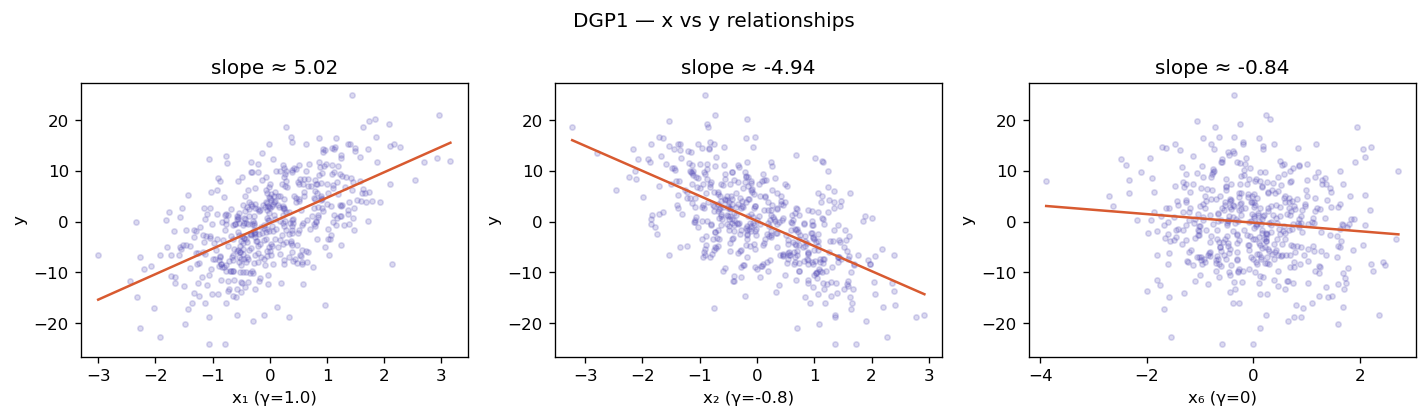

In [3]:
# visualise DGP1 -- scatter x1 vs y
X, d, y, _ = dgp1(n=N, p=P, s=S, beta0=BETA0, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, j, lbl in zip(axes, [0, 1, 5], ['x₁ (γ=1.0)', 'x₂ (γ=-0.8)', 'x₆ (γ=0)']):
    ax.scatter(X[:, j], y, alpha=0.2, s=10, color='#534AB7')
    m, b = np.polyfit(X[:, j], y, 1)
    xr = np.linspace(X[:, j].min(), X[:, j].max(), 100)
    ax.plot(xr, m * xr + b, color='#D85A30', linewidth=1.5)
    ax.set_xlabel(lbl)
    ax.set_ylabel('y')
    ax.set_title(f'slope ≈ {m:.2f}')

fig.suptitle('DGP1 — x vs y relationships', fontweight='500')
plt.tight_layout()

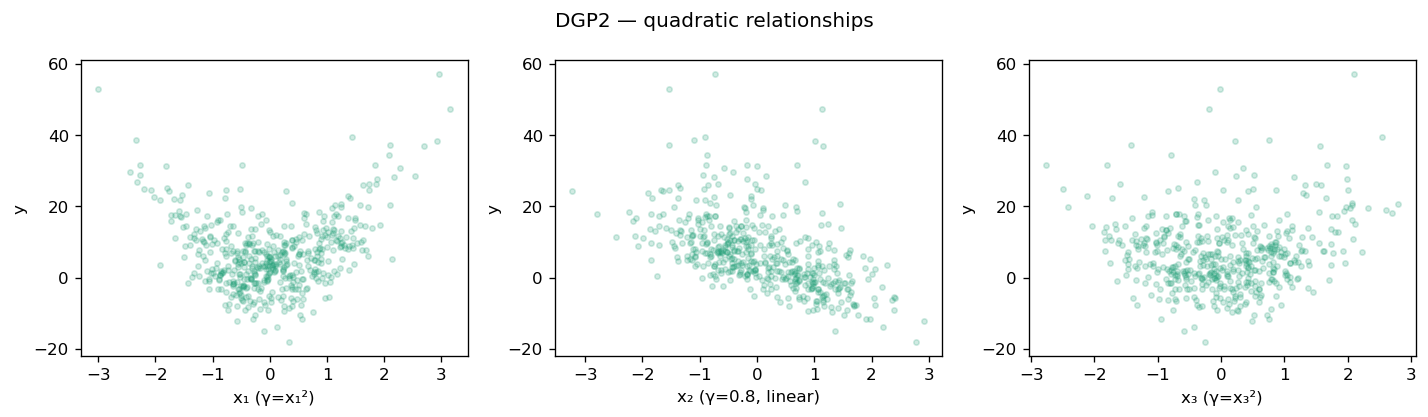

In [4]:
# visualise DGP2 -- nonlinear relationships
X, d, y, _ = dgp2(n=N, p=P, s=S, beta0=BETA0, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, j, lbl in zip(axes, [0, 1, 2], ['x₁ (γ=x₁²)', 'x₂ (γ=0.8, linear)', 'x₃ (γ=x₃²)']):
    ax.scatter(X[:, j], y, alpha=0.2, s=10, color='#1D9E75')
    ax.set_xlabel(lbl)
    ax.set_ylabel('y')

fig.suptitle('DGP2 — quadratic relationships', fontweight='500')
plt.tight_layout()

---
## 3. Single estimator walkthrough
Step through PDS-LASSO manually to understand what gets selected.

In [5]:
# DGP1 -- manual PDS-LASSO walkthrough
X, d, y, beta0 = dgp1(n=N, p=P, s=S, beta0=BETA0, seed=42)

def theoretical_lambda(n, p, c=1.1, alpha=0.05):
    return (c / np.sqrt(n)) * norm.ppf(1 - alpha / (2 * p))

lam = theoretical_lambda(N, P)
print(f'Theoretical lambda: {lam:.4f}')

# LASSO y on X
lasso_y = Lasso(alpha=lam, max_iter=10000).fit(X, y)
S_y     = set(np.where(lasso_y.coef_ != 0)[0])

# LASSO d on X
lasso_d = Lasso(alpha=lam, max_iter=10000).fit(X, d)
S_d     = set(np.where(lasso_d.coef_ != 0)[0])

S_union = sorted(S_y | S_d)

print(f'S_y    (from y ~ X): {sorted(S_y)}')
print(f'S_d    (from d ~ X): {sorted(S_d)}')
print(f'S_union            : {S_union}')
print(f'True nonzero       : {list(range(S))}')

Theoretical lambda: 0.1619
S_y    (from y ~ X): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
S_d    (from d ~ X): []
S_union            : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
True nonzero       : [0, 1, 2, 3, 4, 5]


In [6]:
# post-selection OLS
col_names = ['d'] + [f'x{i+1}' for i in range(P)]
df_data   = pd.DataFrame(np.column_stack([d, X]), columns=col_names)
df_data['y'] = y

X_pds   = sm.add_constant(df_data[['d'] + [f'x{i+1}' for i in S_union]])
pds_res = sm.OLS(df_data['y'], X_pds).fit(cov_type='HC1')
print(pds_res.summary())
print(f'\nTrue beta0 = {beta0}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     4243.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        10:58:25   Log-Likelihood:                -719.81
No. Observations:                 500   AIC:                             1456.
Df Residuals:                     492   BIC:                             1489.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0648      0.046      1.400      0.1

---
## 4. Monte Carlo simulation
Run all DGP × estimator combinations.

> **Note:** Set `N_REPS = 50` for a quick development run. Use `N_REPS = 500` for final results.

In [7]:
# define which DGPs and estimators to run
# exclude epds here until PySR pipeline is validated
DGP_KEYS = ['dgp1', 'dgp2', 'dgp3', 'dgp4', 'dgp5']
EST_KEYS  = ['naive_ols', 'pds_lasso', 'dml_lasso', 'dml_nn']

combined = run_all(
    dgp_registry       = DGP_REGISTRY,
    estimator_registry = ESTIMATOR_REGISTRY,
    dgp_keys           = DGP_KEYS,
    estimator_keys     = EST_KEYS,
    n                  = N,
    p                  = P,
    s                  = S,
    beta0              = BETA0,
    n_reps             = N_REPS,
    n_jobs             = 1,     # set to -1 to use all cores
    save_dir           = '../results',
)

print(f'\nTotal rows: {len(combined)}')
print(combined.groupby(['dgp', 'estimator'])['beta_hat'].count())


Running: Linear sparse × Naive OLS


Replications: 100%|██████████| 30/30 [00:00<00:00, 1794.92it/s]


  Saved to ../results/dgp1_naive_ols.csv

Running: Linear sparse × PDS-LASSO


Replications: 100%|██████████| 30/30 [00:00<00:00, 731.68it/s]


  Saved to ../results/dgp1_pds_lasso.csv

Running: Linear sparse × DML-LASSO


...

  Saved to ../results/dgp5_pds_lasso.csv

Running: Mixed nonlinear + confounding × DML-LASSO


Replications: 100%|██████████| 30/30 [00:00<00:00, 134.61it/s]


  Saved to ../results/dgp5_dml_lasso.csv

Running: Mixed nonlinear + confounding × DML-NN


Replications: 100%|██████████| 30/30 [00:26<00:00,  1.14it/s]

  Saved to ../results/dgp5_dml_nn.csv

All results saved to ../results/all_results.csv

Total rows: 600
dgp   estimator
dgp1  dml_lasso    30
      dml_nn       30
      naive_ols    30
      pds_lasso    30
dgp2  dml_lasso    30
      dml_nn       30
      naive_ols    30
      pds_lasso    30
dgp3  dml_lasso    30
      dml_nn       30
      naive_ols    30
      pds_lasso    30
dgp4  dml_lasso    30
      dml_nn       30
      naive_ols    30
      pds_lasso    30
dgp5  dml_lasso    30
      dml_nn       30
      naive_ols    30
      pds_lasso    30
Name: beta_hat, dtype: int64


---
## 5. Results

In [8]:
# compute metrics
metrics = evaluate_all(combined, beta0=BETA0)
print_summary(metrics, beta0=BETA0)


True ATE: 0.5

BIAS
------------------------------------------------------------
                               DML-LASSO  DML-NN  Naive OLS  PDS-LASSO
DGP                                                                   
Interactions + linear            -0.0187  0.0796     0.0136    -0.0286
Linear sparse                     0.0006  0.0745    -0.0436    -0.0009
Mixed nonlinear                   0.1732  0.2782     0.1612     0.1461
Mixed nonlinear + confounding     0.1585  0.2692     0.3728     0.1472
Quadratic + linear               -0.0485 -0.0199    -0.0486    -0.0779

RMSE
------------------------------------------------------------
                               DML-LASSO  DML-NN  Naive OLS  PDS-LASSO
DGP                                                                   
Interactions + linear             0.2472  0.3317     0.4039     0.2531
Linear sparse                     0.0533  0.1377     0.4205     0.0430
Mixed nonlinear                   0.4713  0.5327     0.5383     0.4395

In [9]:
# RMSE table -- publication ready
print('RMSE')
print(summary_table(metrics, metric='rmse').to_string())
print()
print('Coverage')
print(summary_table(metrics, metric='coverage').to_string())

RMSE
                               DML-LASSO  DML-NN  Naive OLS  PDS-LASSO
DGP                                                                   
Interactions + linear             0.2472  0.3317     0.4039     0.2531
Linear sparse                     0.0533  0.1377     0.4205     0.0430
Mixed nonlinear                   0.4713  0.5327     0.5383     0.4395
Mixed nonlinear + confounding     0.4197  0.4257     0.4088     0.4433
Quadratic + linear                0.3833  0.4057     0.5173     0.3501

Coverage
                               DML-LASSO  DML-NN  Naive OLS  PDS-LASSO
DGP                                                                   
Interactions + linear             0.9667  0.9000     0.8667     0.9667
Linear sparse                     0.9667  0.8667     0.9333     1.0000
Mixed nonlinear                   0.9667  0.9000     0.9000     0.9667
Mixed nonlinear + confounding     0.9333  0.8333     0.6333     0.9667
Quadratic + linear                0.9667  0.9000     0.9667   

Saved: ../figures/dist_dgp1.png


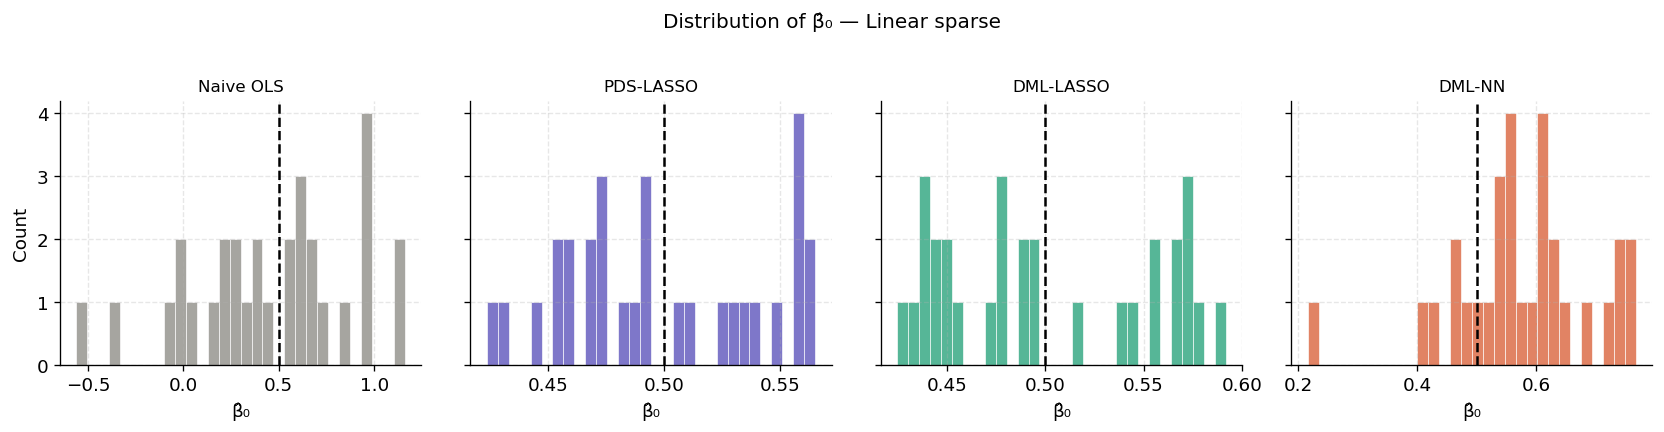

Saved: ../figures/dist_dgp2.png


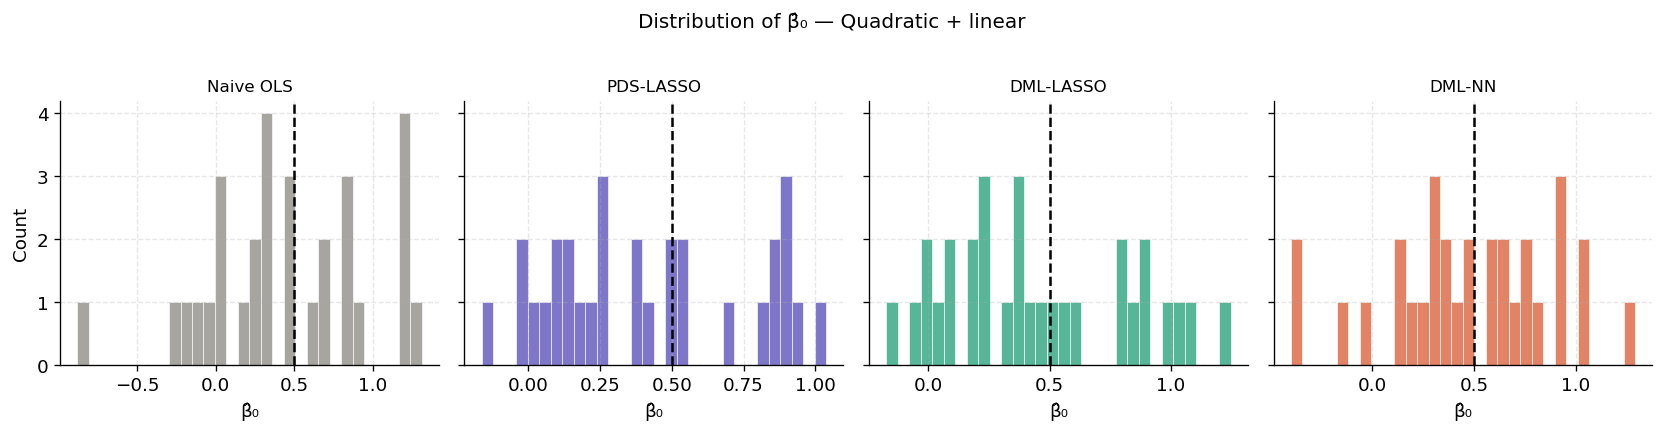

Saved: ../figures/dist_dgp3.png


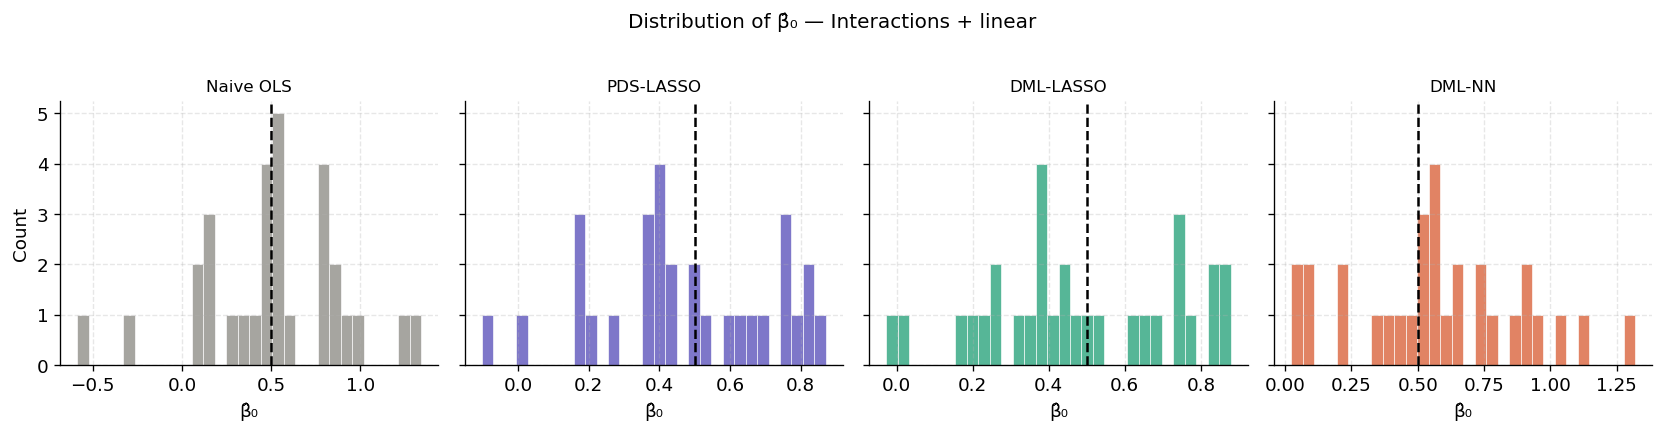

Saved: ../figures/dist_dgp4.png


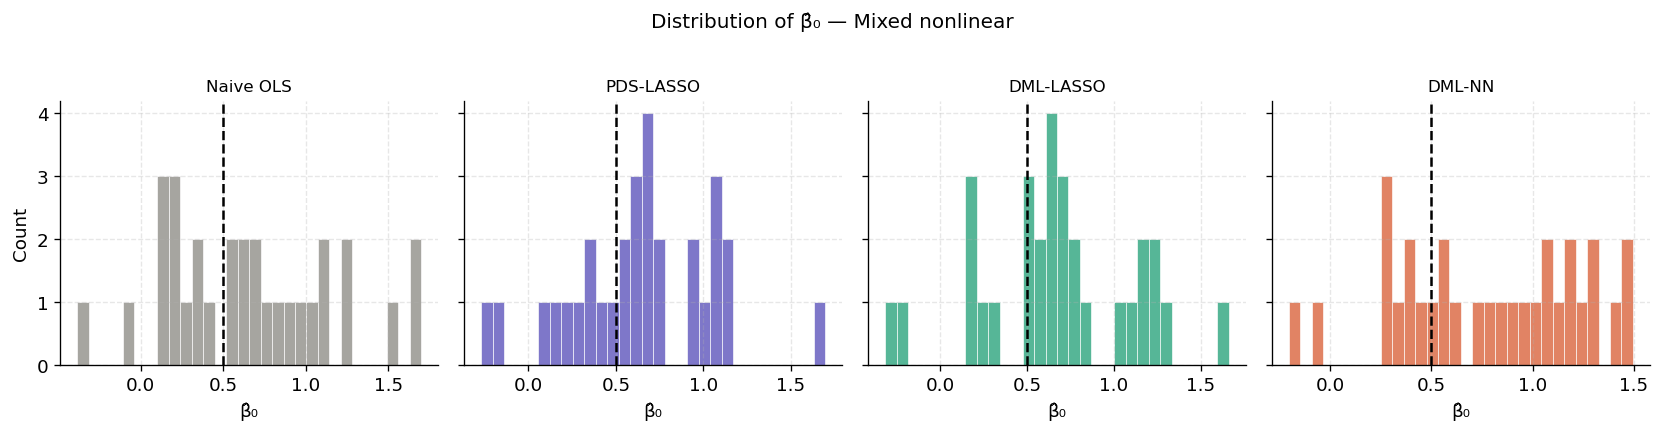

Saved: ../figures/dist_dgp5.png


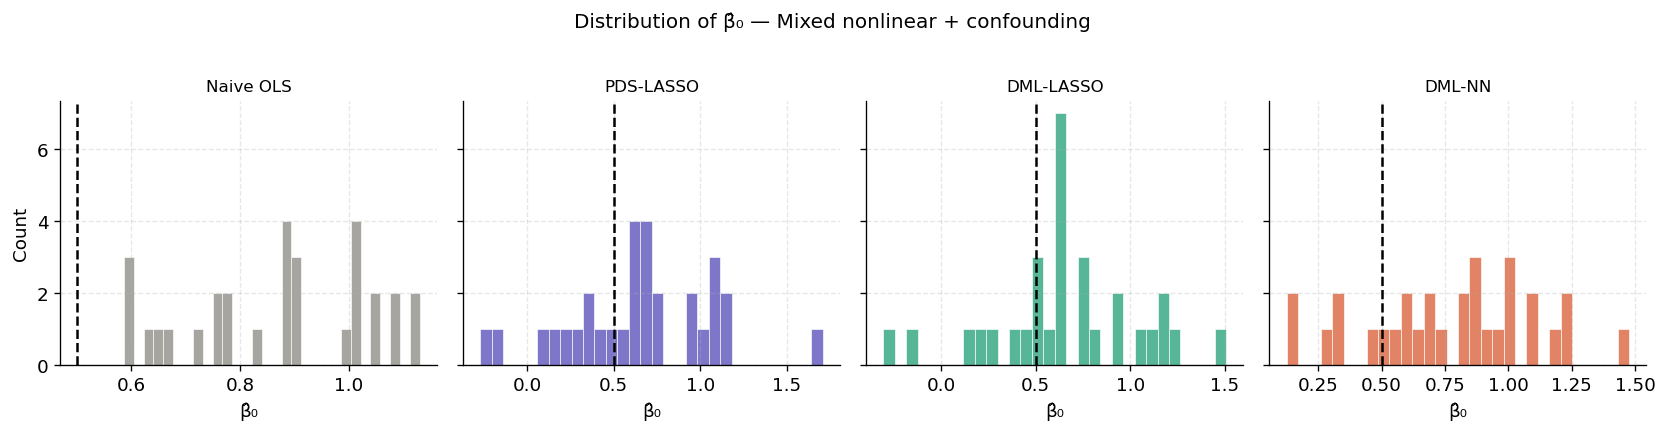

In [10]:
# distribution plots for each DGP
for dgp_key in DGP_KEYS:
    fig = plot_distributions(combined, beta0=BETA0, dgp_key=dgp_key)
    plt.show()

Saved: ../figures/coverage.png


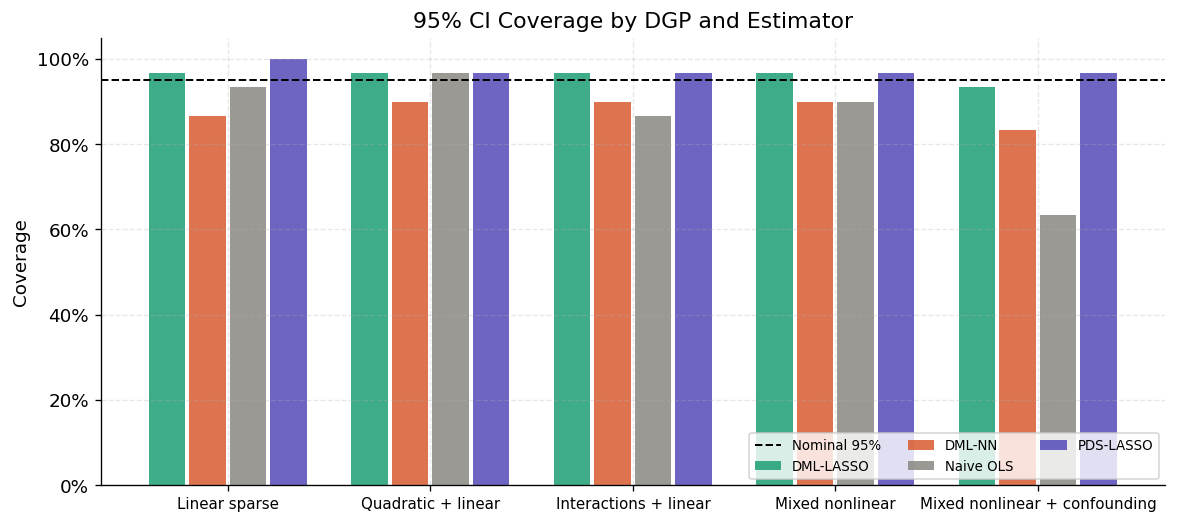

In [11]:
# coverage bar chart
fig = plot_coverage(metrics)
plt.show()

Saved: ../figures/bias.png


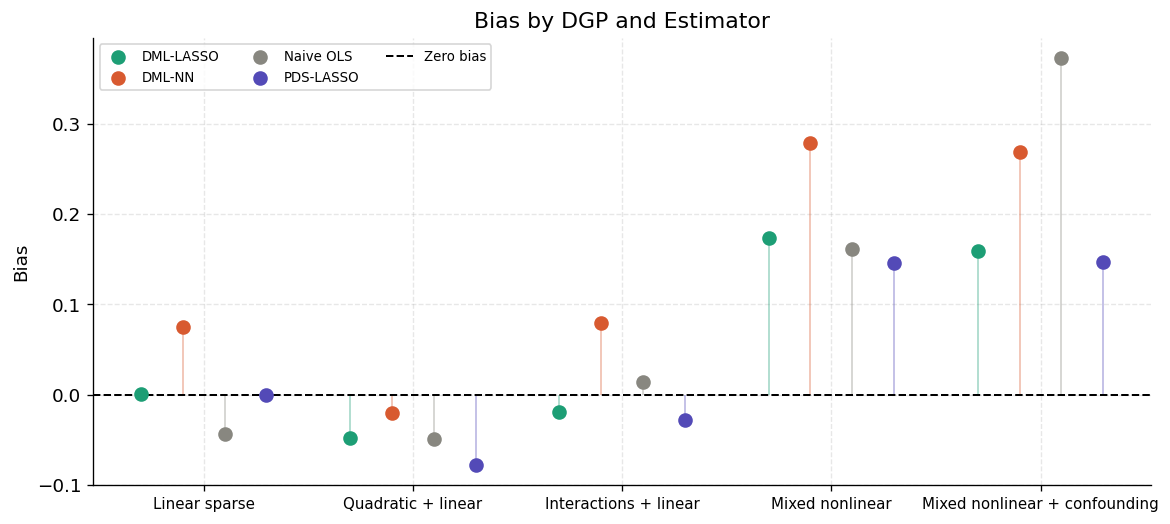

In [12]:
# bias plot
fig = plot_bias(metrics)
plt.show()

Saved: ../figures/rmse_heatmap.png


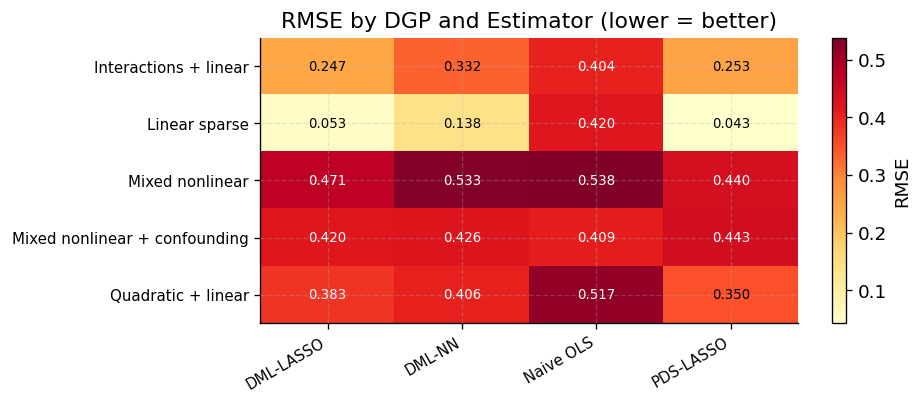

In [13]:
# RMSE heatmap
fig = plot_rmse_heatmap(metrics)
plt.show()

Saved: ../figures/summary_panel.png


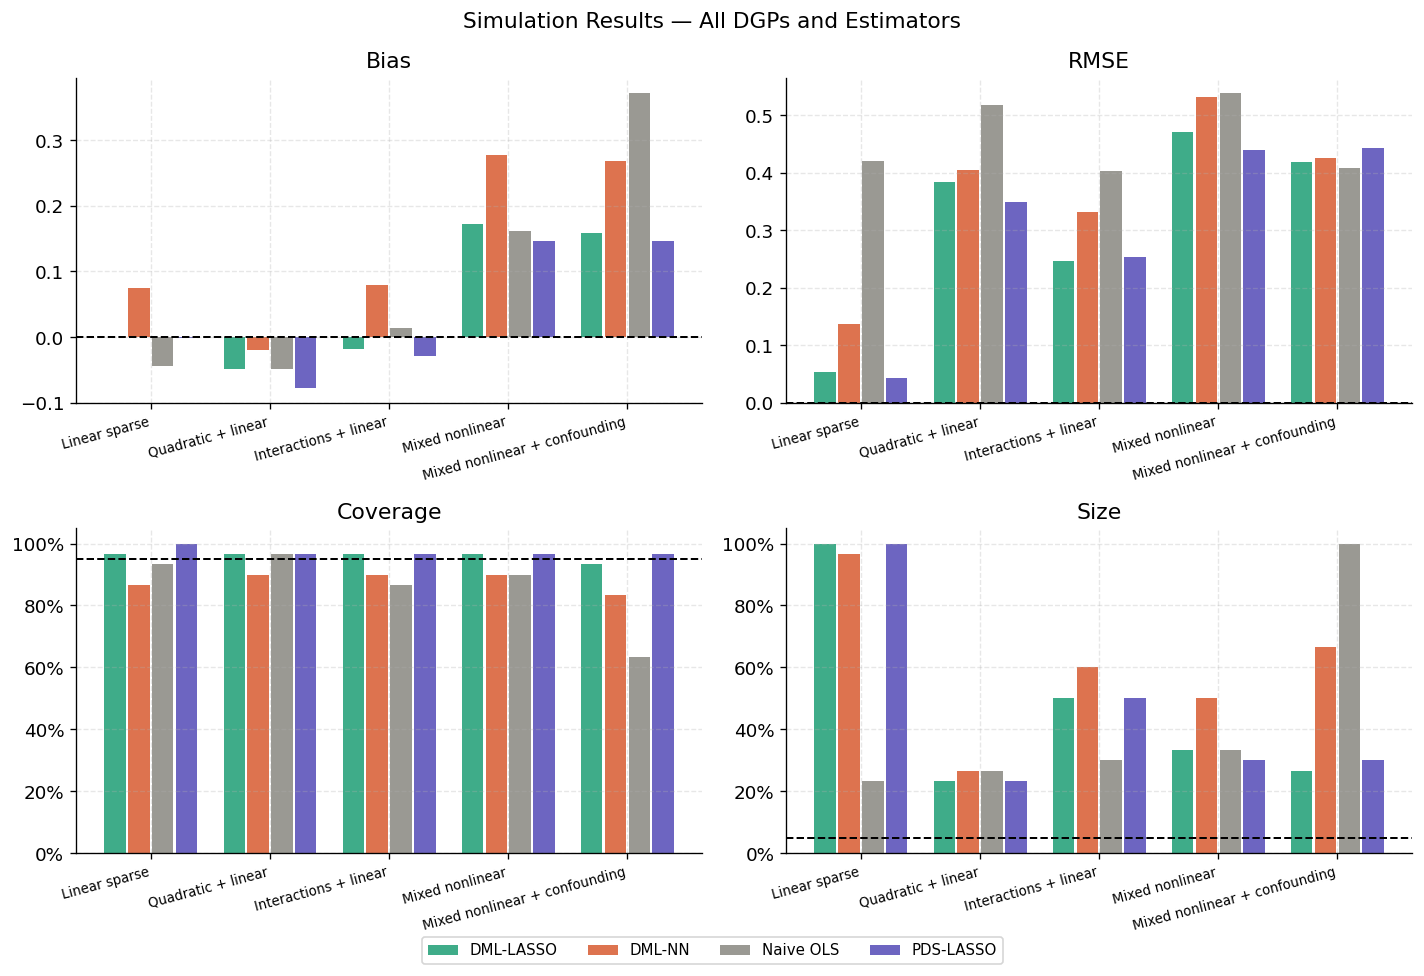

In [14]:
# 2x2 summary panel
fig = plot_summary_panel(metrics)
plt.show()

---
## 6. PySR functional form recovery
Run PySR on each DGP to check what functional forms it recovers.
This is the enrichment step of EPDS.

In [15]:
from pysr import PySRRegressor

def run_pysr(dgp_fn, dgp_label, n=500, p=50, s=6, beta0=0.5, seed=42,
             niterations=40):
    """Run PySR on a DGP and print recovered equations."""
    print(f'\n{"-"*60}')
    print(f'DGP: {dgp_label}')
    print(f'{"-"*60}')

    X, d, y, _ = dgp_fn(n=n, p=p, s=s, beta0=beta0, seed=seed)

    # use selected variables only -- in practice comes from NFSRD
    # here we cheat and use true support for illustration
    X_sel  = X[:, :s]
    X_pysr = np.column_stack([d, X_sel])
    cols   = ['d'] + [f'x{i+1}' for i in range(s)]

    model = PySRRegressor(
        niterations    = niterations,
        binary_operators = ['+', '-', '*'],
        unary_operators  = ['square', 'log', 'sqrt'],
        maxsize          = 30,
        parsimony        = 0.0005,
        procs            = 0,
        random_state     = 42,
        verbosity        = 0,
    )
    model.fit(X_pysr, y, variable_names=cols)

    print(f'Best equation : {model.sympy()}')
    print(f'LaTeX         : {model.latex()}')
    print(f'\nPareto frontier:')
    print(model.equations_[['complexity', 'loss', 'score', 'equation']]
          .to_string(index=False))

    return model

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [16]:
# DGP1 -- should recover linear equation
model_dgp1 = run_pysr(dgp1, 'Linear sparse')


------------------------------------------------------------
DGP: Linear sparse
------------------------------------------------------------


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


Best equation : x5 - x6 + (x3 - x4 + (x1 - x2)*1.6948204)*2.954744
LaTeX         : x_{5} - x_{6} + \left(x_{3} - x_{4} + \left(x_{1} - x_{2}\right) 1.69\right) 2.95

Pareto frontier:
 complexity      loss    score                                                                                                                        equation
          1 67.790810 0.000000                                                                                                                              x5
          3 43.532337 0.221461                                                                                                                 x2 * -4.9279246
          5 20.230688 0.383152                                                                                                           (x1 - x2) * 5.0069036
          7 13.701821 0.194836                                                                                                     ((x1 - x2) - x4) * 4.381172
          9  7.572025 

In [17]:
# DGP2 -- should recover x1^2 and x3^2
model_dgp2 = run_pysr(dgp2, 'Quadratic + linear', s=6)


------------------------------------------------------------
DGP: Quadratic + linear
------------------------------------------------------------


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


Best equation : x5 + (x1**2 - x2 + (x3**2 - x4)*0.6005711)*5.0156045
LaTeX         : x_{5} + \left(x_{1}^{2} - x_{2} + \left(x_{3}^{2} - x_{4}\right) 0.601\right) 5.02

Pareto frontier:
 complexity       loss    score                                                                                                                                             equation
          1 100.983740 0.000000                                                                                                                                            6.8848395
          3  88.871820 0.063882                                                                                                                                   square(square(x1))
          4  55.191640 0.476384                                                                                                                               square(x1 * 2.4309936)
          6  29.955837 0.305544                                                           

In [18]:
# DGP3 -- should recover x1*x2 and x4*x5
model_dgp3 = run_pysr(dgp3, 'Interactions + linear', s=6)


------------------------------------------------------------
DGP: Interactions + linear
------------------------------------------------------------


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


Best equation : x2*x1*5.055408 - ((x3 + (-x4*x5 + x6)*0.5940981)*5.0606856 - 0.055650648)
LaTeX         : x_{2} x_{1} \cdot 5.06 - \left(\left(x_{3} + \left(- x_{4} x_{5} + x_{6}\right) 0.594\right) 5.06 - 0.0556\right)

Pareto frontier:
 complexity      loss    score                                                                                                                                 equation
          1 69.112360 0.000000                                                                                                                                        d
          3 48.109035 0.181132                                                                                                                          x3 * -4.8068776
          5 42.788696 0.058598                                                                                                                    (x3 * -4.774567) - x6
          7 21.271759 0.349447                                                            

In [19]:
# DGP4 -- should recover x1^2*x2, log(x3), x4*x5
model_dgp4 = run_pysr(dgp4, 'Mixed nonlinear', s=6, niterations=80)


------------------------------------------------------------
DGP: Mixed nonlinear
------------------------------------------------------------


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


Best equation : 5.03397317401202*x1**2*x2 + 2.6347601*x4*x5 - 2.6347601*x6 - 2.6347601*log(x3**2)
LaTeX         : 5.03 x_{1}^{2} x_{2} + 2.63 x_{4} x_{5} - 2.63 x_{6} - 2.63 \log{\left(x_{3}^{2} \right)}

Pareto frontier:
 complexity       loss    score                                                                                                                                                     equation
          1 121.802444 0.000000                                                                                                                                                    3.5442407
          3 108.477730 0.057928                                                                                                                                                x2 * 4.978328
          4 100.752150 0.073881                                                                                                                                       square(x2 + 1.7216159)
          5  87.237045

---
## 7. EPDS full run
Once PySR recovery looks good above, run EPDS in the Monte Carlo simulation.

In [20]:
from estimators import epds

# run EPDS on nonlinear DGPs only
epds_results = run_all(
    dgp_registry       = DGP_REGISTRY,
    estimator_registry = {'epds': {'fn': epds, 'label': 'EPDS (ours)'}},
    dgp_keys           = ['dgp2', 'dgp3', 'dgp4', 'dgp5'],
    n                  = N,
    p                  = P,
    s                  = S,
    beta0              = BETA0,
    n_reps             = N_REPS,
    save_dir           = '../results',
)

# combine with existing results for comparison
all_results = pd.concat([combined, epds_results], ignore_index=True)
all_metrics = evaluate_all(all_results, beta0=BETA0)

print_summary(all_metrics, beta0=BETA0)


Running: Quadratic + linear × EPDS (ours)


Replications:   0%|          | 0/30 [00:00<?, ?it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
Replications:   3%|▎         | 1/30 [00:01<00:45,  1.55s/it]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-d

  Saved to ../results/dgp2_epds.csv

Running: Interactions + linear × EPDS (ours)


Replications:   0%|          | 0/30 [00:00<?, ?it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
Replications:   3%|▎         | 1/30 [00:01<00:46,  1.59s/it]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-d

  Saved to ../results/dgp3_epds.csv

Running: Mixed nonlinear × EPDS (ours)


Replications:   0%|          | 0/30 [00:00<?, ?it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
Replications:   3%|▎         | 1/30 [00:01<00:42,  1.48s/it]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-d

  Saved to ../results/dgp4_epds.csv

Running: Mixed nonlinear + confounding × EPDS (ours)


Replications:   0%|          | 0/30 [00:00<?, ?it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
Replications:   3%|▎         | 1/30 [00:01<00:48,  1.66s/it]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-d

  Saved to ../results/dgp5_epds.csv

All results saved to ../results/all_results.csv

True ATE: 0.5

BIAS
------------------------------------------------------------
                               DML-LASSO  DML-NN  EPDS (ours)  Naive OLS  PDS-LASSO
DGP                                                                                
Interactions + linear            -0.0187  0.0796      -0.0017     0.0136    -0.0286
Linear sparse                     0.0006  0.0745          NaN    -0.0436    -0.0009
Mixed nonlinear                   0.1732  0.2782       0.1368     0.1612     0.1461
Mixed nonlinear + confounding     0.1585  0.2692       0.0656     0.3728     0.1472
Quadratic + linear               -0.0485 -0.0199      -0.0135    -0.0486    -0.0779

RMSE
------------------------------------------------------------
                               DML-LASSO  DML-NN  EPDS (ours)  Naive OLS  PDS-LASSO
DGP                                                                                
Interactio

In [26]:
epds_results['est_label'] = 'EPDS'

all_results = pd.concat([combined, epds_results], ignore_index=True)
all_metrics = evaluate_all(all_results, beta0=BETA0)

In [27]:
# ============================================================
# COMPREHENSIVE COMPARISON TABLE
# ============================================================
from IPython.display import display
import pandas as pd

equations = {
    'Linear sparse'                : 'y = 0.5d + 5x1 - 5x2 + 3x3 - 3x4 + x5 - x6 + e',
    'Quadratic + linear'           : 'y = 0.5d + 5x1^2 - 5x2 + 3x3^2 - 3x4 + x5 + e',
    'Interactions + linear'        : 'y = 0.5d + 5x1*x2 - 5x3 + 3x4*x5 - 3x6 + e',
    'Mixed nonlinear'              : 'y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e',
    'Mixed nonlinear + confounding': 'y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e, d = Xd + v',
}

# ordered columns -- PDS-LASSO and EPDS adjacent
COL_ORDER = ['Naive OLS', 'DML-LASSO', 'DML-NN', 'PDS-LASSO', 'EPDS']

print(f'True ATE = {BETA0}  |  n = {N}  |  p = {P}  |  s = {S}  |  reps = {N_REPS}\n')

for metric, caption, cmap in [
    ('bias',     'Bias',                        'RdYlGn_r'),
    ('rmse',     'RMSE',                        'RdYlGn_r'),
    ('coverage', 'Coverage (nominal = 0.95)',   'RdYlGn'),
    ('size',     'Size',                        'RdYlGn_r'),
]:
    pivot = summary_table(all_metrics, metric=metric)

    # reorder columns
    available = [c for c in COL_ORDER if c in pivot.columns]
    pivot     = pivot[available]

    # add equation column
    pivot.insert(0, 'True equation', [equations.get(i, '') for i in pivot.index])

    numeric_cols = [c for c in pivot.columns if c != 'True equation']

    display(
        pivot.style
        .set_caption(caption)
        .format({c: '{:.4f}' for c in numeric_cols})
        .background_gradient(subset=numeric_cols, cmap=cmap, axis=None)
    )

True ATE = 0.5  |  n = 500  |  p = 50  |  s = 6  |  reps = 30



,True equation,Naive OLS,DML-LASSO,DML-NN,PDS-LASSO,EPDS
DGP,,,,,,
Interactions + linear,y = 0.5d + 5x1*x2 - 5x3 + 3x4*x5 - 3x6 + e,0.0136,-0.0187,0.0796,-0.0286,-0.0017
Linear sparse,y = 0.5d + 5x1 - 5x2 + 3x3 - 3x4 + x5 - x6 + e,-0.0436,0.0006,0.0745,-0.0009,nan
Mixed nonlinear,y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e,0.1612,0.1732,0.2782,0.1461,0.1368
Mixed nonlinear + confounding,"y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e, d = Xd + v",0.3728,0.1585,0.2692,0.1472,0.0656
Quadratic + linear,y = 0.5d + 5x1^2 - 5x2 + 3x3^2 - 3x4 + x5 + e,-0.0486,-0.0485,-0.0199,-0.0779,-0.0135


,True equation,Naive OLS,DML-LASSO,DML-NN,PDS-LASSO,EPDS
DGP,,,,,,
Interactions + linear,y = 0.5d + 5x1*x2 - 5x3 + 3x4*x5 - 3x6 + e,0.4039,0.2472,0.3317,0.2531,0.2916
Linear sparse,y = 0.5d + 5x1 - 5x2 + 3x3 - 3x4 + x5 - x6 + e,0.4205,0.0533,0.1377,0.0430,nan
Mixed nonlinear,y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e,0.5383,0.4713,0.5327,0.4395,0.6714
Mixed nonlinear + confounding,"y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e, d = Xd + v",0.4088,0.4197,0.4257,0.4433,0.4536
Quadratic + linear,y = 0.5d + 5x1^2 - 5x2 + 3x3^2 - 3x4 + x5 + e,0.5173,0.3833,0.4057,0.3501,0.2055


,True equation,Naive OLS,DML-LASSO,DML-NN,PDS-LASSO,EPDS
DGP,,,,,,
Interactions + linear,y = 0.5d + 5x1*x2 - 5x3 + 3x4*x5 - 3x6 + e,0.8667,0.9667,0.9000,0.9667,0.9333
Linear sparse,y = 0.5d + 5x1 - 5x2 + 3x3 - 3x4 + x5 - x6 + e,0.9333,0.9667,0.8667,1.0000,nan
Mixed nonlinear,y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e,0.9000,0.9667,0.9000,0.9667,0.8667
Mixed nonlinear + confounding,"y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e, d = Xd + v",0.6333,0.9333,0.8333,0.9667,0.9000
Quadratic + linear,y = 0.5d + 5x1^2 - 5x2 + 3x3^2 - 3x4 + x5 + e,0.9667,0.9667,0.9000,0.9667,1.0000


,True equation,Naive OLS,DML-LASSO,DML-NN,PDS-LASSO,EPDS
DGP,,,,,,
Interactions + linear,y = 0.5d + 5x1*x2 - 5x3 + 3x4*x5 - 3x6 + e,0.3000,0.5000,0.6000,0.5000,0.6000
Linear sparse,y = 0.5d + 5x1 - 5x2 + 3x3 - 3x4 + x5 - x6 + e,0.2333,1.0000,0.9667,1.0000,nan
Mixed nonlinear,y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e,0.3333,0.3333,0.5000,0.3000,0.3333
Mixed nonlinear + confounding,"y = 0.5d + 5x1^2*x2 - 5log|x3| + 3x4*x5 - 3x6 + e, d = Xd + v",1.0000,0.2667,0.6667,0.3000,0.4000
Quadratic + linear,y = 0.5d + 5x1^2 - 5x2 + 3x3^2 - 3x4 + x5 + e,0.2667,0.2333,0.2667,0.2333,0.5667
